In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# using the same cleaned master table from the previous notebook, so this
# EDA builds on already-cleaned data instead of redoing that work here
master = pd.read_csv('../data/processed/master_cleaned.csv')

# converting timestamp columns back to datetime, since reading from CSV
# resets them to plain strings even though they were datetime before
timestamp_cols = ['order_purchase_timestamp', 'order_approved_at', 
                   'order_delivered_timestamp', 'order_estimated_delivery_date']
for col in timestamp_cols:
    master[col] = pd.to_datetime(master[col])

# basic plot styling so charts look clean and consistent throughout
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Master table shape:', master.shape)
master.head()

Master table shape: (89316, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,product_id,seller_id,price,...,payment_installments,payment_value,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,...,1,259.14,58125,varzea paulista,SP,toys,491.0,19.0,12.0,16.0
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,...,8,382.39,3112,armacao dos buzios,RJ,watches_gifts,440.0,18.0,14.0,17.0
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,...,4,249.25,4119,jandira,SP,costruction_tools_garden,2200.0,16.0,16.0,16.0
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,639iGvMyv0De,jWzS0ayv9TGf,264.50,...,2,27.79,18212,uberlandia,MG,toys,1450.0,68.0,3.0,48.0
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,1lycYGcsic2F,l1pYW6GBnPMr,779.90,...,1,76.15,88868,ilhabela,SP,toys,300.0,17.0,4.0,12.0


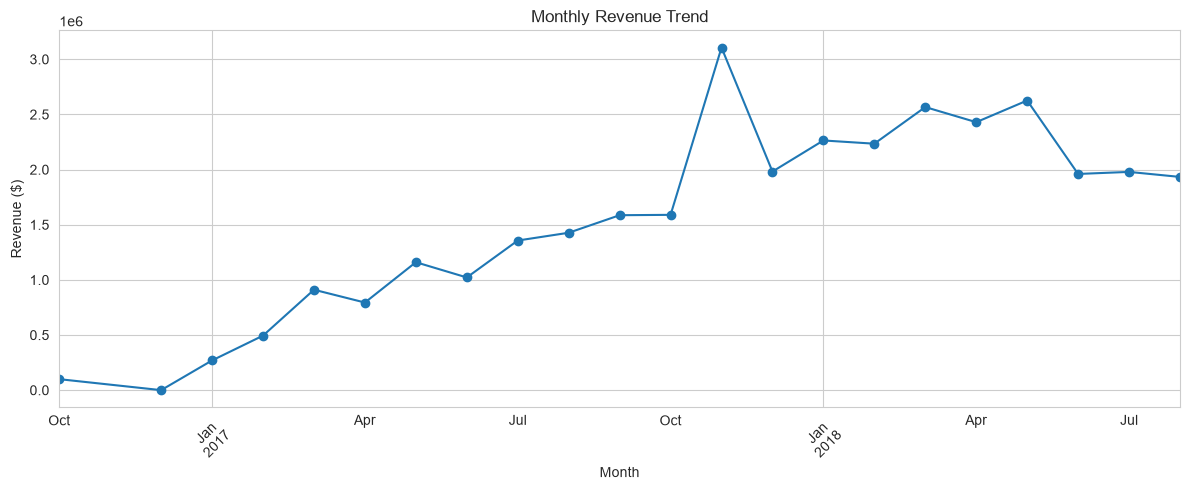

In [5]:
# visualizing the monthly revenue trend already found in SQL 
# (03_sales_analysis.sql) — same numbers, now as an actual chart, 
# since a trend is much easier to read visually than as a table.

delivered = master[master['order_status'] == 'delivered'].copy()
delivered['month'] = delivered['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = delivered.groupby('month').apply(
    lambda x: (x['price'] + x['shipping_charges']).sum()
)

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

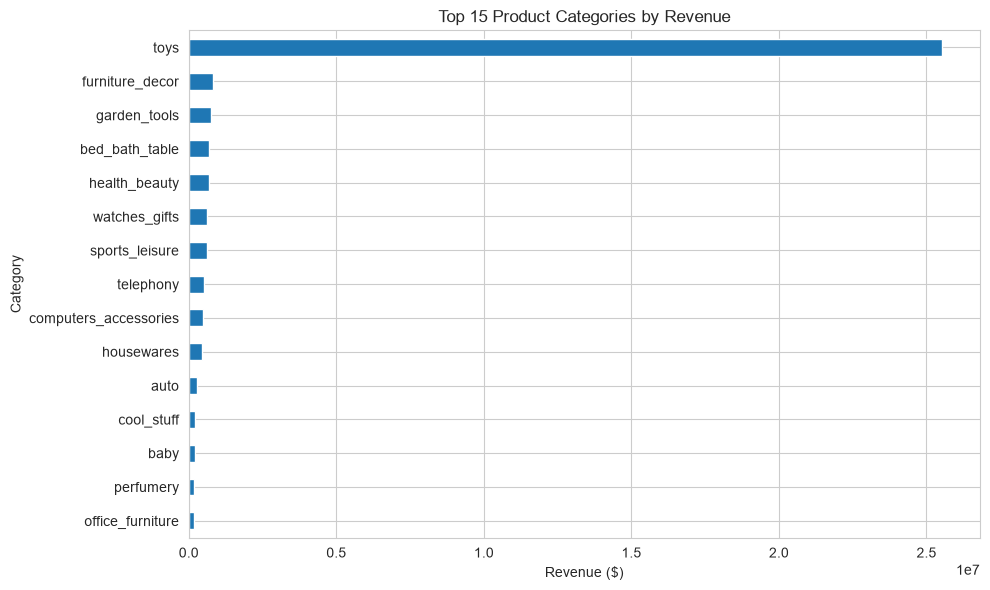

In [6]:
# same category revenue numbers from 03_sales_analysis.sql, now as a bar chart — makes it much easier to see just how dominant "toys" is compared to everything else at a glance.

category_revenue = delivered.groupby('product_category_name').apply(
    lambda x: (x['price'] + x['shipping_charges']).sum()
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
category_revenue.plot(kind='barh')
plt.title('Top 15 Product Categories by Revenue')
plt.xlabel('Revenue ($)')
plt.ylabel('Category')
plt.gca().invert_yaxis()  # highest revenue at the top
plt.tight_layout()
plt.show()

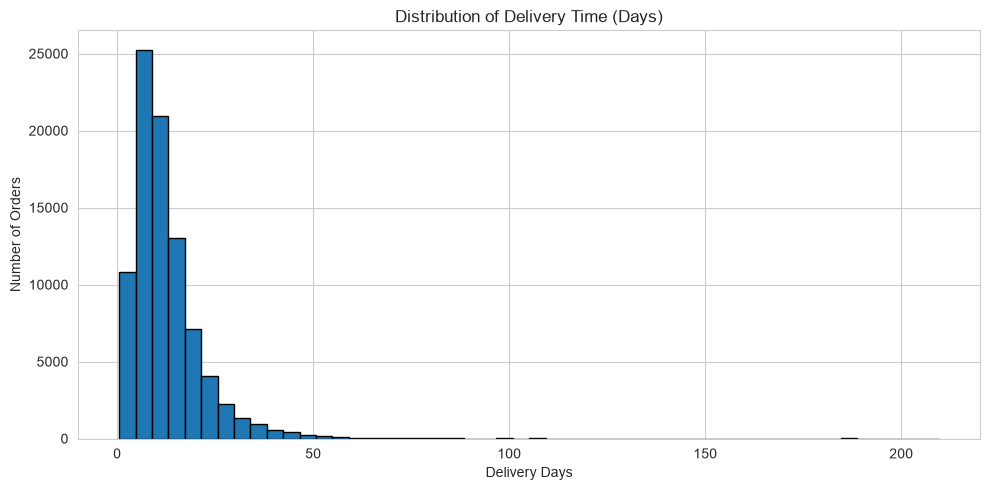

           order_id order_purchase_timestamp order_delivered_timestamp  \
571    pWRjBubXBYdq      2017-02-21 23:31:27       2017-09-19 14:36:39   
68448  I7Uy2GUAWB08      2018-02-23 14:57:35       2018-09-19 23:24:07   
45405  lmRJRLj8XXgP      2017-03-08 18:09:02       2017-09-19 14:33:17   
3145   l7IXVGR1psXu      2017-03-15 11:24:27       2017-09-19 14:38:18   
87475  PLhufnwqAyZ0      2017-03-15 23:23:17       2017-09-19 17:14:25   

       delivery_days  
571       209.628611  
68448     208.351759  
45405     194.850174  
3145      188.134618  
87475     187.743843  


In [7]:
# looking at the actual distribution of delivery times, not just the
# average from SQL — a histogram will show if delivery time is fairly
# consistent or if there's a long tail of slow outliers like the 209-day
# max we saw in 03_sales_analysis.sql

delivered_with_dates = delivered[delivered['order_delivered_timestamp'].notnull()].copy()
delivered_with_dates['delivery_days'] = (
    delivered_with_dates['order_delivered_timestamp'] - delivered_with_dates['order_purchase_timestamp']
).dt.total_seconds() / 86400

plt.figure(figsize=(10, 5))
plt.hist(delivered_with_dates['delivery_days'], bins=50, edgecolor='black')
plt.title('Distribution of Delivery Time (Days)')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

# also pulling up the specific slow outliers directly, not just seeing
# them as a bar in the histogram
print(delivered_with_dates.nlargest(5, 'delivery_days')[
    ['order_id', 'order_purchase_timestamp', 'order_delivered_timestamp', 'delivery_days']
])

In [8]:
# 4 of the 5 slowest orders all delivered on the same date (2017-09-19),
# despite being purchased months apart — that's not random slowness,
# that looks like a systemic delay affecting a batch of orders at once.
# checking how many total orders were delivered on that date to see
# how big this event actually was.

same_day_count = delivered_with_dates[
    delivered_with_dates['order_delivered_timestamp'].dt.date.astype(str) == '2017-09-19'
]
print('Orders delivered on 2017-09-19:', len(same_day_count))
print()
print(same_day_count['delivery_days'].describe())

Orders delivered on 2017-09-19: 248

count    248.000000
mean      25.577186
std       40.147805
min        1.137141
25%        7.941586
50%       12.085359
75%       19.115376
max      209.628611
Name: delivery_days, dtype: float64


In [9]:
# 12-day median delivery on this date looks normal, but the small
# subset of very old orders dragged the average way up. before calling
# this a systemic event, checking if 248 orders is even an unusually
# high volume for a single delivery day, or just a normal day that
# happened to include a few backlog orders.

daily_delivery_counts = delivered_with_dates.groupby(
    delivered_with_dates['order_delivered_timestamp'].dt.date
).size()

print('Average orders delivered per day:', round(daily_delivery_counts.mean(), 1))
print('Orders delivered on 2017-09-19:', daily_delivery_counts.loc[pd.Timestamp('2017-09-19').date()])
print()
print(daily_delivery_counts.describe())

Average orders delivered per day: 137.2
Orders delivered on 2017-09-19: 248

count    637.000000
mean     137.240188
std      113.062196
min        1.000000
25%       22.000000
50%      121.000000
75%      235.000000
max      415.000000
dtype: float64


In [10]:
# these extreme delays (150+ days) are real outliers, not part of a
# single systemic event based on the daily volume check above. keeping
# a record of them here rather than just discarding, since knowing they
# exist matters for interpreting delivery time averages elsewhere in
# this project (e.g. the 12.4-day average from 03_sales_analysis.sql
# is only slightly pulled up by these, since they're a tiny fraction
# of 87k+ orders).

extreme_delays = delivered_with_dates[delivered_with_dates['delivery_days'] > 100]
print('Orders with delivery time over 100 days:', len(extreme_delays))
print('As a percent of all delivered orders:', round(100 * len(extreme_delays) / len(delivered_with_dates), 3), '%')

Orders with delivery time over 100 days: 44
As a percent of all delivered orders: 0.05 %
